Simulated Annealing Plots

In [207]:
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [208]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-13_18-33-09.npy'
brute_force_data_directory = './data/brute_force/test' # use same as in cl_optimizer_experiments

In [209]:
import numpy as np

result_tensor = np.load(results_path)

In [210]:
result_tensor.shape # should be a 6-tuple: (n_problem_sizes, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 2)

(19, 10, 10, 2, 11, 2)

In [211]:
loss_tensor = result_tensor[..., 1]
temp_iterations = result_tensor[0, 0, 0, 0, :, 0]

In [212]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

extract_candidate_dimension = lambda p: np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_candidates').group(1)))
extract_load_factor = lambda p: float(re.search(string=str(p.name), pattern=r'_(\d*\.\d*)_load_factor').group(1))

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(extract_candidate_dimension(p), extract_load_factor(p), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dim', 'load factor', 'path'])
df = df.groupby(['dim', 'load factor'])['path'].agg(list).reset_index()

In [213]:
problem_sizes = df['dim'].unique()
load_factors = df['load factor'].unique()
brute_force_data_paths = np.array(df['path'].to_list(), dtype=object).reshape(len(problem_sizes), len(load_factors), -1)

problem_sizes = problem_sizes

In [214]:
import pandas as pd
import numpy as np
brute_force_data = np.vectorize(pd.read_csv)(brute_force_data_paths)
loss_spaces = [[np.array([d['loss'] for d in da]) for da in data] for data in brute_force_data] # needs to be list because is inhomogeneous

In [215]:
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=3)
raars = np.array([[[[raar(avg, loss_spaces[i][j][k, :]) for avg in avg_loss]for k, avg_loss in enumerate(avg_loss_runs_per_load_factor)] for j, avg_loss_runs_per_load_factor in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])
mean_raars_per_load_factor = raars.mean(axis=(0, 1))
std_raars_per_load_factor = raars.std(axis=(0, 1))

In [216]:
mean_raars = raars.mean(axis=(0, 1, 2))
std_raars = raars.std(axis=(0, 1, 2))

In [217]:
min_losses = np.array([[s.min(axis=1) for s in spaces] for spaces in loss_spaces])

def get_min_loss_candidates(min_loss: float, data: pd.DataFrame):
    mask = np.isclose(data['loss'], min_loss, rtol=1e-9)
    return data[mask]['candidate'].to_numpy()

min_loss_candidates = np.vectorize(get_min_loss_candidates)(min_losses, brute_force_data)

C:\Users\moritz\Desktop\UCP-PaperV2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get_min_loss_candidates (vectorized)
  outputs = ufunc(*args, out=...)


In [218]:
min_loss_candidates.shape

(19, 10, 10)

In [219]:
optimal_candidates_found = np.count_nonzero(loss_tensor ==  min_losses.reshape(min_losses.shape[0], min_losses.shape[1], min_losses.shape[2], 1, 1), axis=3)
p_star = (optimal_candidates_found.T / loss_tensor.shape[-1]).T

In [220]:
from metrics import tts_p
tts_ps = np.apply_along_axis(tts_p, axis=-1, arr=p_star)

mask = np.any(np.isfinite(tts_ps), axis=(0, 1, 2))
non_inf_tts_ps = tts_ps[..., mask] # filter np.inf values

In [221]:
mask.shape

(11,)

In [222]:
# TTS(p) | Temperature Iterations (p)
finite_mask = np.any(np.isfinite(non_inf_tts_ps), axis=-1, keepdims=True)

masked = np.ma.masked_invalid(non_inf_tts_ps)
mean_tts_ps_per_load_factor = masked.mean(axis=(0, 1)).data
std_tts_ps_per_load_factor = masked.std(axis=(0, 1)).data

In [223]:
mean_tts_ps = masked.mean(axis=(0, 1, 2)).data
std_tts_ps = masked.std(axis=(0, 1, 2)).data

In [224]:
# TTS* | Problem Size N
masked = np.ma.masked_invalid(non_inf_tts_ps)
min_tts = masked.min(axis=-1).squeeze().data
avg_min_tts_per_load_factor = min_tts.mean(axis=-1)
std_min_tts_per_load_factor = min_tts.std(axis=-1)

In [225]:
avg_min_tts = min_tts.mean(axis=(-1, 1))
std_min_tts = min_tts.std(axis=(-1, 1))

In [226]:
std_min_tts.shape

(19,)

10


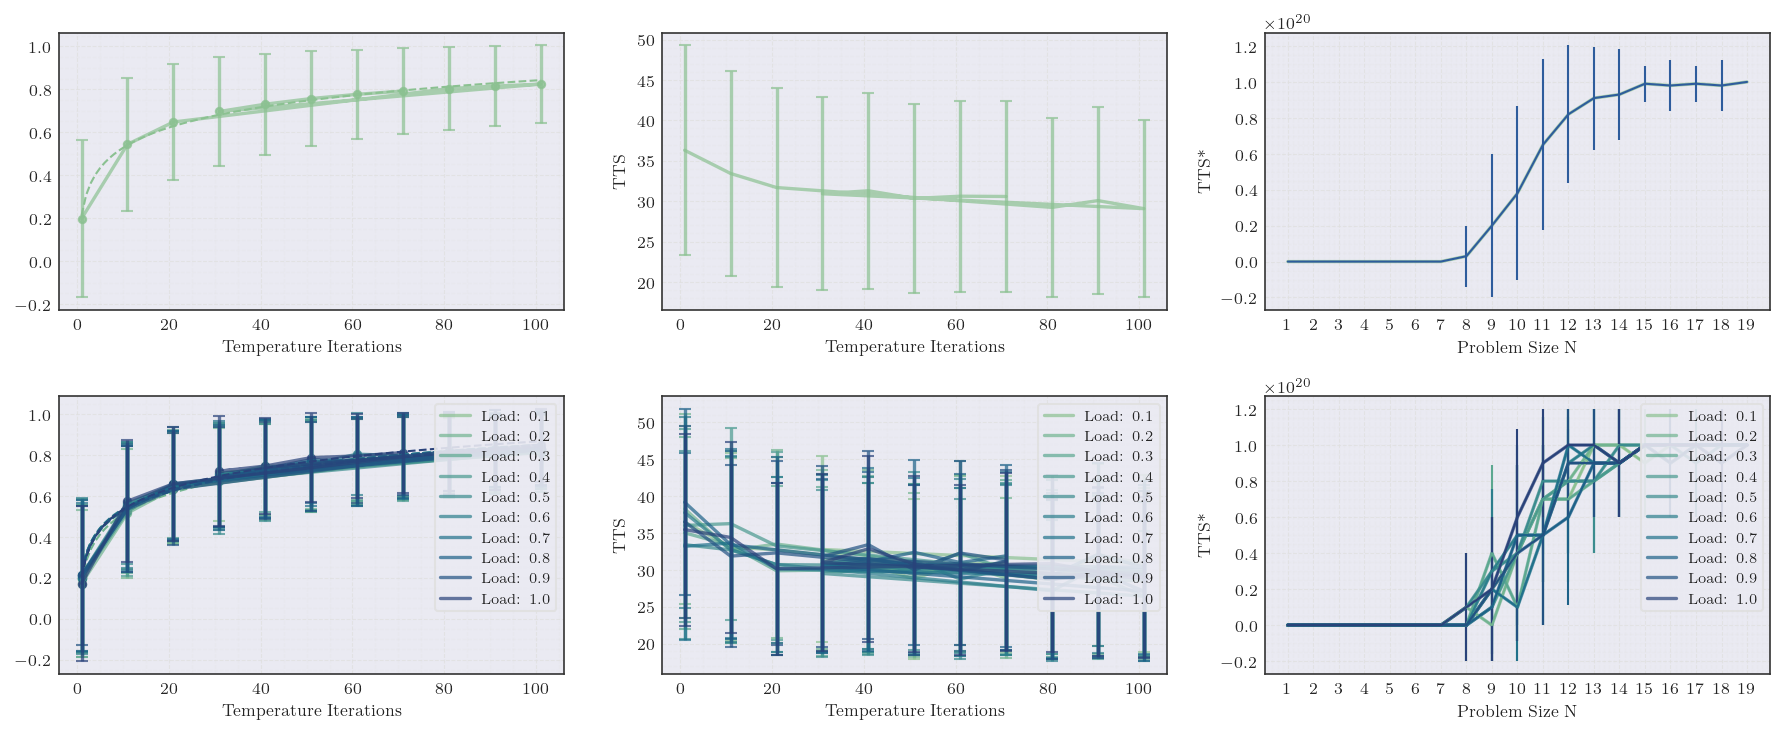

In [227]:
from datetime import datetime
import styling
import seaborn as sns

styling.set_my_style()

palette = sns.color_palette("crest", len(load_factors))
print(len(palette))


fig, ax = styling.subplots(2, 3, figsize=(12, 5))
ax = ax.flatten()

ax[0].set_xlabel('Temperature Iterations')
ax[0].plot(
    temp_iterations,
    mean_raars,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax[0].errorbar(
    temp_iterations,
    mean_raars,
    yerr=std_raars,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=temp_iterations, y=mean_raars, color=palette[0], ax=ax[0], line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

ax[1].plot(
    temp_iterations[mask],
    mean_tts_ps,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax[1].errorbar(
    temp_iterations[mask],
    y=mean_tts_ps,
    yerr=std_tts_ps,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)
ax[1].set_ylabel('TTS')
ax[1].set_xlabel('Temperature Iterations')
ax[1].grid(visible=True)

ax[2].plot(
    problem_sizes,
    avg_min_tts,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax[2].set_xticks(problem_sizes)

ax[2].errorbar(
    problem_sizes,
    y=avg_min_tts,
    yerr=std_min_tts,
)
ax[2].set_ylabel('TTS*')
ax[2].set_xlabel('Problem Size N')
ax[2].grid(visible=True)

ax[3].set_xlabel('Temperature Iterations')
for i, (load_factor, mean_raar, std_raar) in enumerate(zip(load_factors, mean_raars_per_load_factor, std_raars_per_load_factor)):
    ax[3].plot(
        temp_iterations,
        mean_raar,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )


    ax[3].errorbar(
        temp_iterations,
        mean_raar,
        yerr=std_raar,
        fmt="none",
        capsize=3,
        color=palette[i],
        alpha=0.7,
        linewidth=1.6
    )

    sns.regplot(x=temp_iterations, y=mean_raar, color=palette[i], ax=ax[3], line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)
ax[3].legend(loc='upper right')


for i, (load_factor, mean_tts, std_pps) in enumerate(zip(load_factors, mean_tts_ps_per_load_factor, std_tts_ps_per_load_factor)):
    ax[4].plot(
        temp_iterations[mask],
        mean_tts,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )

    ax[4].errorbar(
        temp_iterations[mask],
        y=mean_tts,
        yerr=std_pps,
        fmt="none",
        capsize=3,
        color=palette[i],
        alpha=0.7,
        linewidth=1.6
    )
ax[4].set_ylabel('TTS')
ax[4].set_xlabel('Temperature Iterations')
ax[4].grid(visible=True)
ax[4].legend(loc='upper right')


for i, (load_factor, mean, std) in enumerate(zip(load_factors, avg_min_tts_per_load_factor.T, std_min_tts_per_load_factor.T)):
    ax[5].plot(
        problem_sizes,
        mean,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )

    ax[5].set_xticks(problem_sizes)

    ax[5].errorbar(
        problem_sizes,
        y=mean,
        yerr=std,
        color=palette[i],
    )
ax[5].set_ylabel('TTS*')
ax[5].set_xlabel('Problem Size N')
ax[5].grid(visible=True)
ax[5].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'./plots/simulated_annealing_performance_summary_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png')